# 04 — Difference-in-Differences Analysis

This notebook implements the core causal inference methods:
1. Classic 2×2 DiD (pre/post × expansion/non-expansion)
2. Two-Way Fixed Effects (TWFE) with staggered treatment
3. Event Study estimation and visualization
4. Discussion of TWFE bias and motivation for modern estimators (see R scripts)

**Input:** `data/processed/analysis_panel.csv`  
**Output:** Regression tables, event study plots

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
import warnings
import os

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

os.makedirs('../figures', exist_ok=True)
os.makedirs('../tables', exist_ok=True)

# Load data
panel = pd.read_csv('../data/processed/analysis_panel.csv')
print(f"Panel: {panel.shape}")
print(f"States: {panel['state'].nunique()}, Years: {panel['year'].min()}–{panel['year'].max()}")

Panel: (663, 32)
States: 51, Years: 2010–2022


In [2]:
# Identify available outcome variables
outcome_candidates = [
    'allcause_age_adj_rate', 'allcause_crude_rate',
    'diabetes_age_adj_rate', 'diabetes_crude_rate', 'diabetes_prevalence',
    'maternal_age_adj_rate', 'maternal_crude_rate',
    'low_birth_weight_pct'
]
outcome_vars = [c for c in outcome_candidates if c in panel.columns and panel[c].notna().sum() > 100]

# Identify available control variables
control_candidates = [
    'median_household_income', 'poverty_rate', 'total_population',
    'pct_white', 'pct_black', 'pct_hispanic',
    'uninsured_rate', 'unemployment_rate'
]
control_vars = [c for c in control_candidates if c in panel.columns and panel[c].notna().sum() > 100]

print(f"Outcome variables available: {outcome_vars if outcome_vars else 'NONE — download CDC data first'}")
print(f"Control variables available: {control_vars if control_vars else 'NONE — get Census API key first'}")

if not outcome_vars:
    print("\n⚠️  No outcome data found. This notebook needs CDC data to run the regressions.")
    print("For now, we'll demonstrate the methodology using control variables as placeholder outcomes.")
    # Use ACS vars as demo outcomes if no health outcomes available
    outcome_vars = [c for c in ['poverty_rate', 'median_household_income'] if c in panel.columns]

Outcome variables available: ['allcause_age_adj_rate', 'allcause_crude_rate', 'diabetes_age_adj_rate', 'diabetes_crude_rate', 'diabetes_prevalence', 'maternal_age_adj_rate', 'maternal_crude_rate']
Control variables available: ['median_household_income', 'poverty_rate', 'total_population', 'pct_white', 'pct_black', 'pct_hispanic']


---
## 1. Classic 2×2 Difference-in-Differences

The simplest DiD: compare changes in outcomes before/after 2014 for expansion vs non-expansion states.

$$Y_{st} = \alpha + \beta_1 \cdot Expansion_s + \beta_2 \cdot Post_t + \delta \cdot (Expansion_s \times Post_t) + \epsilon_{st}$$

- $\delta$ is the DiD estimate (our causal parameter of interest)

In [3]:
def run_simple_did(panel, outcome_var, controls=None):
    """
    Run a simple 2x2 DiD regression.
    Only uses early adopters (2014) vs never-expanded states.
    """
    # Filter to clean 2x2 comparison
    # Treatment: states that expanded in 2014
    # Control: states that never expanded
    df = panel[
        (panel['expansion_year'].isin([2014, 0])) &
        (panel[outcome_var].notna())
    ].copy()
    
    df['post'] = (df['year'] >= 2014).astype(int)
    df['treat'] = (df['expansion_year'] == 2014).astype(int)
    df['treat_x_post'] = df['treat'] * df['post']
    
    # Build formula
    formula = f'{outcome_var} ~ treat + post + treat_x_post'
    if controls:
        available_controls = [c for c in controls if c in df.columns and df[c].notna().sum() > 50]
        if available_controls:
            formula += ' + ' + ' + '.join(available_controls)
    
    # Fit with clustered standard errors
    model = smf.ols(formula, data=df).fit(
        cov_type='cluster',
        cov_kwds={'groups': df['state_fips']}
    )
    
    print(f"\n{'='*60}")
    print(f"Simple DiD: {outcome_var}")
    print(f"{'='*60}")
    print(f"Treatment: 2014 expansion states | Control: never-expanded")
    print(f"N = {model.nobs:.0f} | R² = {model.rsquared:.4f}")
    print(f"\n*** DiD Estimate (treat_x_post): {model.params['treat_x_post']:.4f} ***")
    print(f"    Std Error: {model.bse['treat_x_post']:.4f}")
    print(f"    95% CI: [{model.conf_int().loc['treat_x_post', 0]:.4f}, {model.conf_int().loc['treat_x_post', 1]:.4f}]")
    print(f"    p-value: {model.pvalues['treat_x_post']:.4f}")
    
    return model

In [4]:
# Run simple DiD for each outcome
simple_did_results = {}

for outcome in outcome_vars:
    try:
        model = run_simple_did(panel, outcome, controls=control_vars)
        simple_did_results[outcome] = model
    except Exception as e:
        print(f"\n⚠️  Error with {outcome}: {e}")


Simple DiD: allcause_age_adj_rate
Treatment: 2014 expansion states | Control: never-expanded
N = 481 | R² = 0.5637

*** DiD Estimate (treat_x_post): -31.4534 ***
    Std Error: 12.0833
    95% CI: [-55.1362, -7.7705]
    p-value: 0.0092

Simple DiD: allcause_crude_rate
Treatment: 2014 expansion states | Control: never-expanded
N = 481 | R² = 0.4767

*** DiD Estimate (treat_x_post): -47.8665 ***
    Std Error: 17.4568
    95% CI: [-82.0811, -13.6518]
    p-value: 0.0061

Simple DiD: diabetes_age_adj_rate
Treatment: 2014 expansion states | Control: never-expanded
N = 481 | R² = 0.4834

*** DiD Estimate (treat_x_post): -1.4980 ***
    Std Error: 0.7502
    95% CI: [-2.9683, -0.0277]
    p-value: 0.0458

Simple DiD: diabetes_crude_rate
Treatment: 2014 expansion states | Control: never-expanded
N = 481 | R² = 0.4251

*** DiD Estimate (treat_x_post): -2.0807 ***
    Std Error: 0.9857
    95% CI: [-4.0126, -0.1488]
    p-value: 0.0348

Simple DiD: diabetes_prevalence
Treatment: 2014 expansio

---
## 2. Two-Way Fixed Effects (TWFE) DiD

Accounts for staggered treatment timing using state and year fixed effects:

$$Y_{st} = \alpha_s + \lambda_t + \delta \cdot D_{st} + X_{st}\gamma + \epsilon_{st}$$

Where $\alpha_s$ = state fixed effects, $\lambda_t$ = year fixed effects, $D_{st}$ = treatment indicator.

In [5]:
def run_twfe(panel, outcome_var, controls=None):
    """
    Run TWFE DiD with state and year fixed effects.
    Uses all states including staggered adopters.
    """
    df = panel[panel[outcome_var].notna()].copy()
    
    # Set panel index for linearmodels
    df = df.set_index(['state_fips', 'year'])
    
    # Build dependent and independent variables
    y = df[outcome_var]
    
    exog_vars = ['post_expansion']
    if controls:
        available = [c for c in controls if c in df.columns and df[c].notna().sum() > 50]
        exog_vars += available
    
    X = df[exog_vars].copy()
    
    # Drop rows with any NaN in X
    mask = X.notna().all(axis=1) & y.notna()
    y = y[mask]
    X = X[mask]
    
    # Fit TWFE with entity and time fixed effects
    model = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    ).fit(cov_type='clustered', cluster_entity=True)
    
    print(f"\n{'='*60}")
    print(f"TWFE DiD: {outcome_var}")
    print(f"{'='*60}")
    print(f"All states (staggered adoption) | Entity + Time FE")
    print(f"N = {model.nobs} | R² (within) = {model.rsquared_within:.4f}")
    print(f"\n*** TWFE DiD Estimate (post_expansion): {model.params['post_expansion']:.4f} ***")
    print(f"    Std Error: {model.std_errors['post_expansion']:.4f}")
    print(f"    95% CI: [{model.conf_int().loc['post_expansion', 'lower']:.4f}, {model.conf_int().loc['post_expansion', 'upper']:.4f}]")
    print(f"    p-value: {model.pvalues['post_expansion']:.4f}")
    
    return model

In [6]:
# Run TWFE for each outcome
twfe_results = {}

for outcome in outcome_vars:
    try:
        model = run_twfe(panel, outcome, controls=control_vars)
        twfe_results[outcome] = model
    except Exception as e:
        print(f"\n⚠️  Error with {outcome}: {e}")


TWFE DiD: allcause_age_adj_rate
All states (staggered adoption) | Entity + Time FE
N = 663 | R² (within) = -0.9923

*** TWFE DiD Estimate (post_expansion): 0.1494 ***
    Std Error: 4.4885
    95% CI: [-8.6659, 8.9647]
    p-value: 0.9734



TWFE DiD: allcause_crude_rate
All states (staggered adoption) | Entity + Time FE
N = 663 | R² (within) = -1.5135

*** TWFE DiD Estimate (post_expansion): -1.3602 ***
    Std Error: 5.3637
    95% CI: [-11.8944, 9.1740]
    p-value: 0.7999



TWFE DiD: diabetes_age_adj_rate
All states (staggered adoption) | Entity + Time FE
N = 663 | R² (within) = -0.5253

*** TWFE DiD Estimate (post_expansion): -0.1568 ***
    Std Error: 0.3990
    95% CI: [-0.9404, 0.6268]
    p-value: 0.6944

TWFE DiD: diabetes_crude_rate
All states (staggered adoption) | Entity + Time FE
N = 663 | R² (within) = -0.9490

*** TWFE DiD Estimate (post_expansion): -0.1607 ***
    Std Error: 0.4690
    95% CI: [-1.0818, 0.7603]
    p-value: 0.7319

TWFE DiD: diabetes_prevalence
All states (staggered adoption) | Entity + Time FE
N = 610 | R² (within) = -1.2454

*** TWFE DiD Estimate (post_expansion): 0.0991 ***
    Std Error: 0.1296
    95% CI: [-0.1555, 0.3538]
    p-value: 0.4448



TWFE DiD: maternal_age_adj_rate
All states (staggered adoption) | Entity + Time FE
N = 299 | R² (within) = -0.0660

*** TWFE DiD Estimate (post_expansion): -0.0213 ***
    Std Error: 0.0895
    95% CI: [-0.1977, 0.1550]
    p-value: 0.8119



TWFE DiD: maternal_crude_rate
All states (staggered adoption) | Entity + Time FE
N = 299 | R² (within) = -0.1249

*** TWFE DiD Estimate (post_expansion): -0.0021 ***
    Std Error: 0.0752
    95% CI: [-0.1503, 0.1461]
    p-value: 0.9776


---
## 3. Event Study

Estimate dynamic treatment effects by year relative to expansion:

$$Y_{st} = \alpha_s + \lambda_t + \sum_{k \neq -1} \delta_k \cdot \mathbb{1}[t - E_s = k] + X_{st}\gamma + \epsilon_{st}$$

This is the most informative visualization — it shows:
- **Pre-treatment coefficients** → test parallel trends (should be ~0)
- **Post-treatment coefficients** → dynamic causal effects

In [7]:
def run_event_study(panel, outcome_var, controls=None, leads=4, lags=8):
    """
    Estimate event study with leads/lags relative to treatment.
    Omits t=-1 as the reference period.
    """
    # Filter to states with expansion info
    df = panel[
        (panel[outcome_var].notna()) &
        (panel['event_time'].notna() | (panel['ever_expanded'] == 0))
    ].copy()
    
    # For never-treated states, they serve as controls
    # Create event time dummies only for treated states
    # Bin endpoints
    df['event_time_binned'] = df['event_time'].copy()
    df.loc[df['event_time_binned'] < -leads, 'event_time_binned'] = -leads
    df.loc[df['event_time_binned'] > lags, 'event_time_binned'] = lags
    
    # Create dummies (excluding t=-1 as reference)
    event_times = sorted([t for t in df['event_time_binned'].dropna().unique() if t != -1])
    
    for t in event_times:
        col_name = f'et_{int(t)}' if t < 0 else f'et_plus_{int(t)}'
        df[col_name] = (df['event_time_binned'] == t).astype(int)
    
    # Set up panel
    df_panel = df.set_index(['state_fips', 'year'])
    y = df_panel[outcome_var]
    
    # Event time dummies
    et_cols = [c for c in df_panel.columns if c.startswith('et_')]
    exog_vars = et_cols.copy()
    
    if controls:
        available = [c for c in controls if c in df_panel.columns and df_panel[c].notna().sum() > 50]
        exog_vars += available
    
    X = df_panel[exog_vars].copy()
    mask = X.notna().all(axis=1) & y.notna()
    y = y[mask]
    X = X[mask]
    
    # Fit
    model = PanelOLS(
        y, X,
        entity_effects=True,
        time_effects=True
    ).fit(cov_type='clustered', cluster_entity=True)
    
    # Extract event study coefficients
    es_coefs = []
    for t in event_times:
        col_name = f'et_{int(t)}' if t < 0 else f'et_plus_{int(t)}'
        if col_name in model.params.index:
            es_coefs.append({
                'event_time': t,
                'coef': model.params[col_name],
                'se': model.std_errors[col_name],
                'ci_lower': model.conf_int().loc[col_name, 'lower'],
                'ci_upper': model.conf_int().loc[col_name, 'upper'],
                'pvalue': model.pvalues[col_name]
            })
    
    # Add reference period (t=-1)
    es_coefs.append({
        'event_time': -1, 'coef': 0, 'se': 0,
        'ci_lower': 0, 'ci_upper': 0, 'pvalue': np.nan
    })
    
    es_df = pd.DataFrame(es_coefs).sort_values('event_time')
    
    return model, es_df

In [8]:
def plot_event_study(es_df, outcome_var, title=None):
    """
    Create a publication-quality event study plot.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Confidence intervals
    ax.fill_between(es_df['event_time'], es_df['ci_lower'], es_df['ci_upper'],
                    alpha=0.2, color='#2171b5')
    
    # Point estimates
    ax.plot(es_df['event_time'], es_df['coef'], 'o-',
            color='#2171b5', linewidth=2, markersize=6)
    
    # Reference lines
    ax.axhline(y=0, color='black', linewidth=0.8)
    ax.axvline(x=-0.5, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    
    # Annotate reference period
    ax.annotate('Reference\nperiod (t=-1)',
                xy=(-1, 0), xytext=(-2.5, ax.get_ylim()[1] * 0.7),
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=9, color='gray', ha='center')
    
    # Labels
    ax.text(-2.5, ax.get_ylim()[0] * 0.9, 'Pre-treatment',
            ha='center', fontsize=10, color='gray', style='italic')
    ax.text(3, ax.get_ylim()[0] * 0.9, 'Post-treatment',
            ha='center', fontsize=10, color='gray', style='italic')
    
    if title is None:
        title = outcome_var.replace('_', ' ').title()
    ax.set_title(f'Event Study: {title}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Years Relative to Medicaid Expansion', fontsize=12)
    ax.set_ylabel('Estimated Effect (95% CI)', fontsize=12)
    
    plt.tight_layout()
    return fig


Event Study: allcause_age_adj_rate
 event_time       coef        se   ci_lower  ci_upper   pvalue
       -4.0  -0.748118  3.688861  -7.993219  6.496983 0.839359
       -3.0   1.304896  3.673953  -5.910927  8.520718 0.722587
       -2.0  -0.570057  2.662700  -5.799729  4.659614 0.830552
       -1.0   0.000000  0.000000   0.000000  0.000000      NaN
        0.0  -2.579417  3.781904 -10.007259  4.848426 0.495484
        1.0  -6.625047  5.849143 -18.113046  4.862952 0.257827
        2.0  -1.345568  5.626909 -12.397089  9.705953 0.811088
        3.0   4.525658  5.617094  -6.506586 15.557901 0.420748
        4.0   7.345642  6.781077  -5.972722 20.664005 0.279143
        5.0   8.421070  8.528916  -8.330133 25.172274 0.323879
        6.0   3.164425  9.617810 -15.725419 22.054269 0.742261
        7.0 -23.074188 13.808283 -50.194325  4.045949 0.095251
        8.0  -1.653069 13.833847 -28.823414 25.517276 0.904925


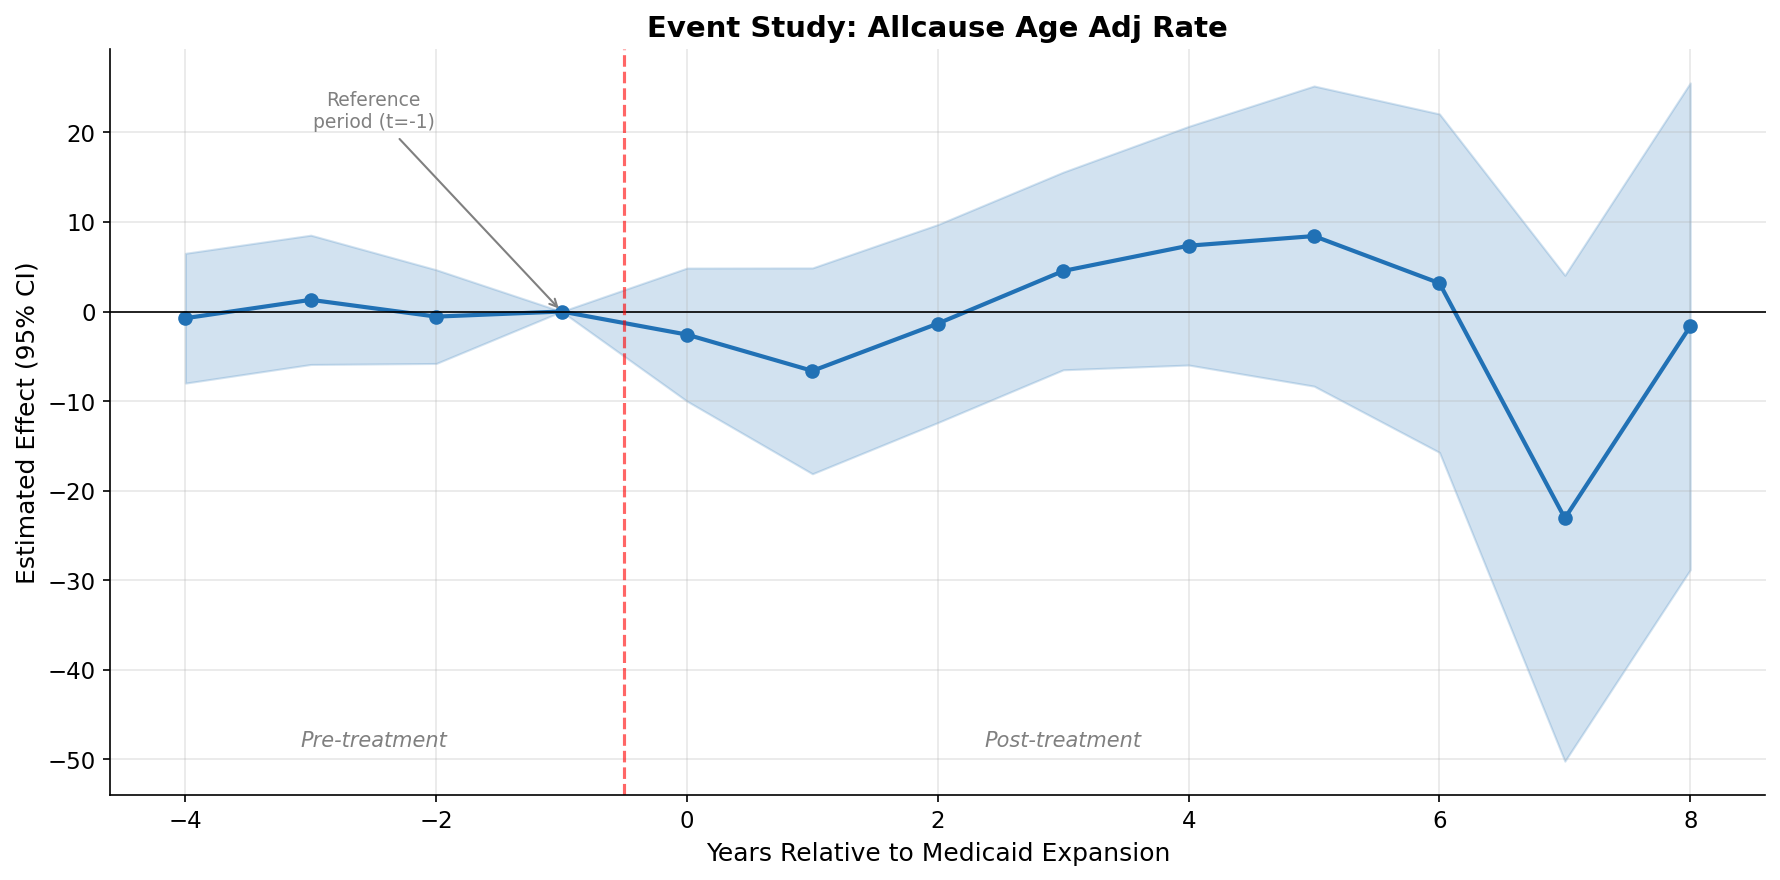

Saved: figures/event_study_allcause_age_adj_rate.png

Event Study: allcause_crude_rate
 event_time       coef        se   ci_lower  ci_upper   pvalue
       -4.0   4.966857  5.340385  -5.521917 15.455631 0.352728
       -3.0   2.742569  4.373900  -5.847982 11.333120 0.530885
       -2.0   0.875292  3.359965  -5.723842  7.474426 0.794565
       -1.0   0.000000  0.000000   0.000000  0.000000      NaN
        0.0  -3.428959  4.855679 -12.965747  6.107829 0.480362
        1.0  -9.234188  7.631005 -24.221850  5.753474 0.226736
        2.0   0.689994  6.722758 -12.513828 13.893817 0.918288
        3.0  11.474241  6.919304  -2.115607 25.064089 0.097797
        4.0  11.554328  8.753064  -5.637114 28.745769 0.187343
        5.0  13.487562 10.888310  -7.897606 34.872731 0.215949
        6.0   8.805409 13.285957 -17.288854 34.899673 0.507746
        7.0 -14.139424 22.510196 -58.350539 30.071691 0.530162
        8.0  14.798659 22.957026 -30.290051 59.887369 0.519425


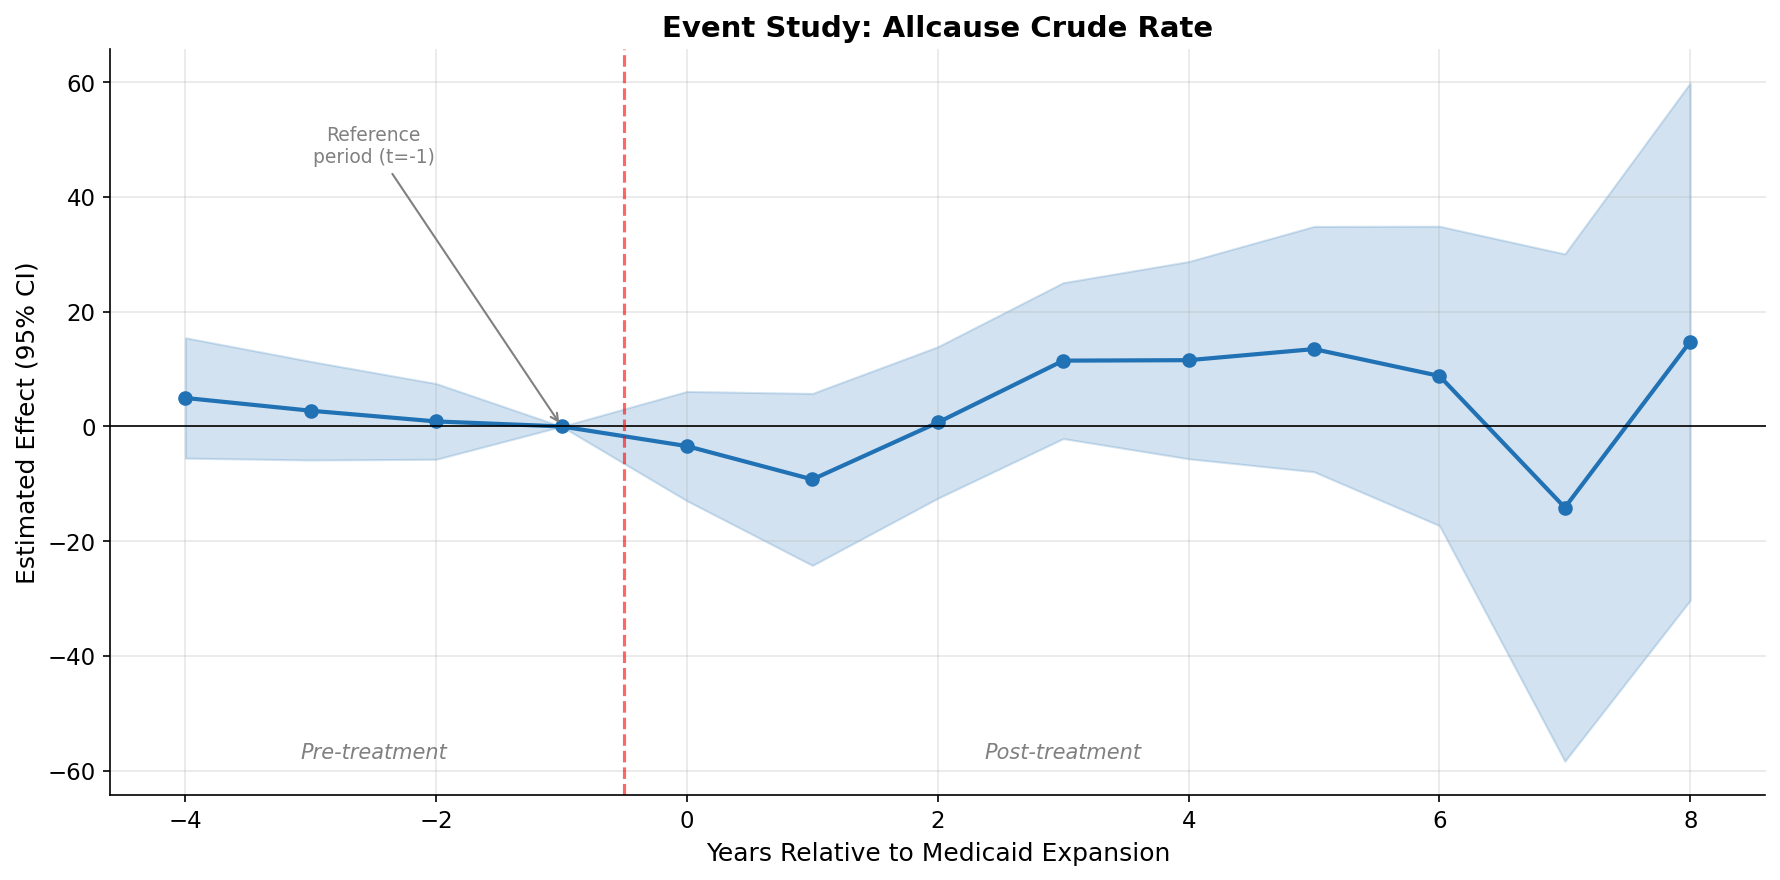

Saved: figures/event_study_allcause_crude_rate.png

Event Study: diabetes_age_adj_rate
 event_time      coef       se  ci_lower  ci_upper   pvalue
       -4.0 -0.209244 0.570985 -1.330687  0.912199 0.714154
       -3.0  0.144092 0.417424 -0.675748  0.963932 0.730074
       -2.0  0.048726 0.371880 -0.681663  0.779116 0.895799
       -1.0  0.000000 0.000000  0.000000  0.000000      NaN
        0.0  0.238437 0.324737 -0.399364  0.876237 0.463096
        1.0 -0.701351 0.510356 -1.703715  0.301012 0.169896
        2.0 -0.585724 0.567819 -1.700948  0.529500 0.302719
        3.0  0.142785 0.687182 -1.206874  1.492444 0.835471
        4.0 -0.158587 0.750772 -1.633139  1.315965 0.832780
        5.0  0.126537 0.859416 -1.561398  1.814472 0.882997
        6.0 -0.618433 0.831257 -2.251063  1.014197 0.457193
        7.0 -0.878389 1.026364 -2.894216  1.137439 0.392446
        8.0 -0.769848 1.169265 -3.066340  1.526644 0.510539


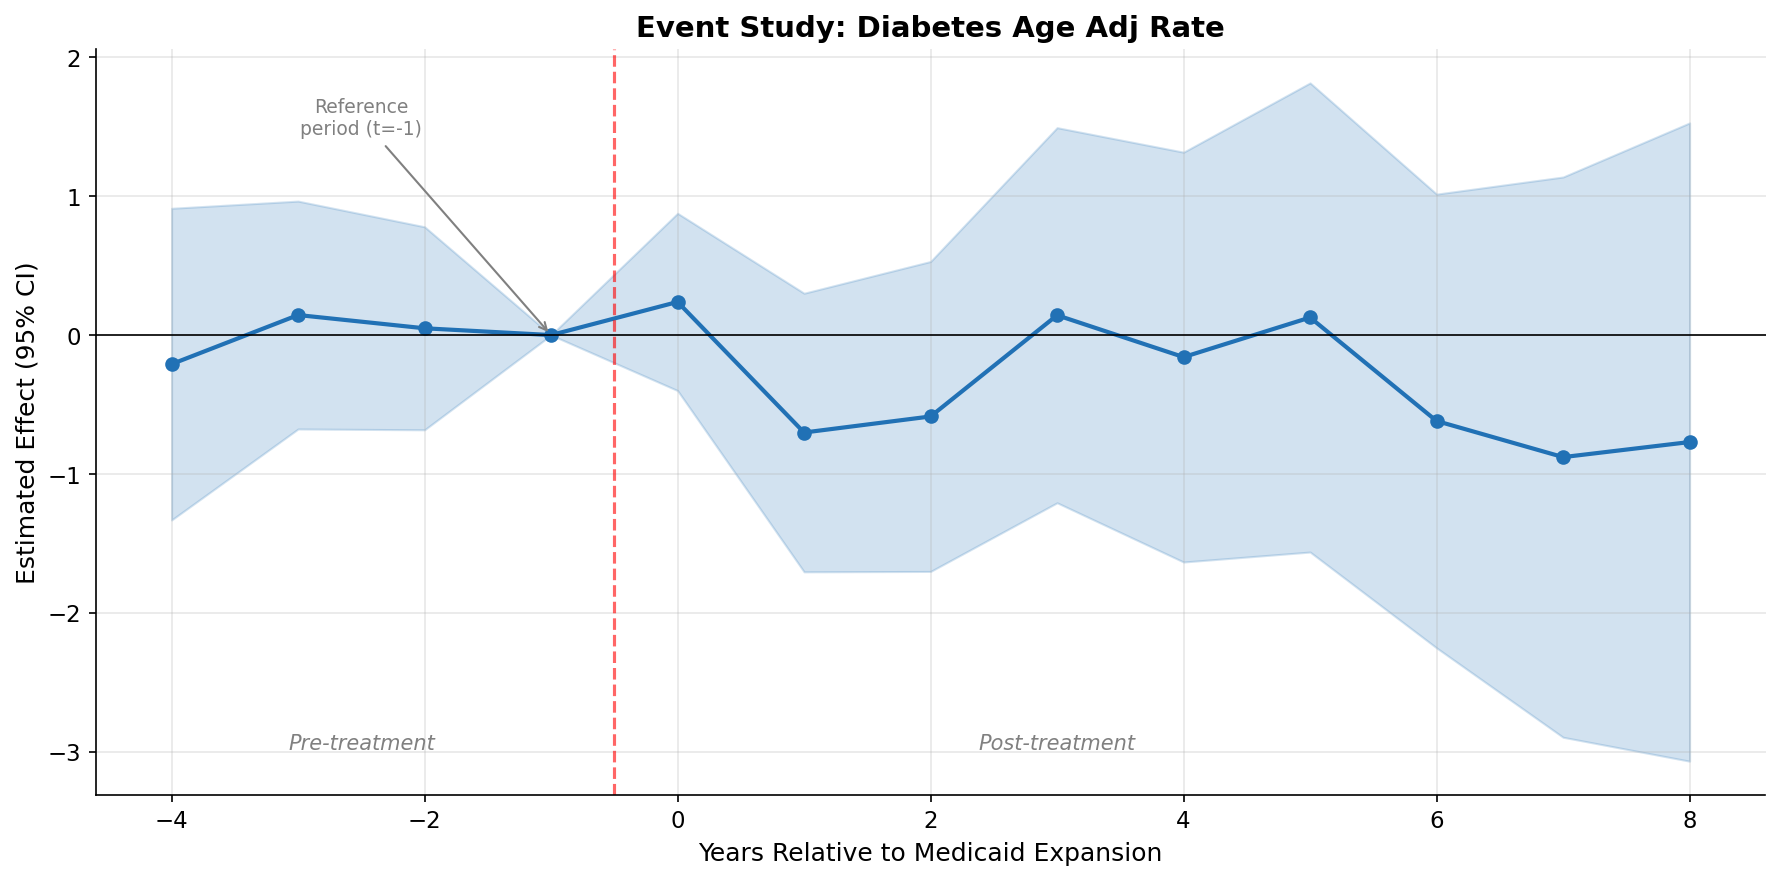

Saved: figures/event_study_diabetes_age_adj_rate.png

Event Study: diabetes_crude_rate
 event_time      coef       se  ci_lower  ci_upper   pvalue
       -4.0 -0.338209 0.737337 -1.786375  1.109957 0.646628
       -3.0  0.174706 0.504275 -0.815714  1.165126 0.729129
       -2.0 -0.087786 0.464303 -0.999699  0.824127 0.850104
       -1.0  0.000000 0.000000  0.000000  0.000000      NaN
        0.0  0.121808 0.371641 -0.608113  0.851728 0.743213
        1.0 -0.872811 0.565963 -1.984390  0.238767 0.123576
        2.0 -0.607406 0.668325 -1.920029  0.705216 0.363806
        3.0  0.457300 0.816601 -1.146544  2.061144 0.575692
        4.0 -0.004001 0.887732 -1.747548  1.739547 0.996406
        5.0  0.375632 1.050385 -1.687374  2.438639 0.720762
        6.0 -0.482332 1.080596 -2.604675  1.640012 0.655505
        7.0 -0.524840 1.390788 -3.256415  2.206735 0.706037
        8.0 -0.094019 1.578192 -3.193665  3.005627 0.952515


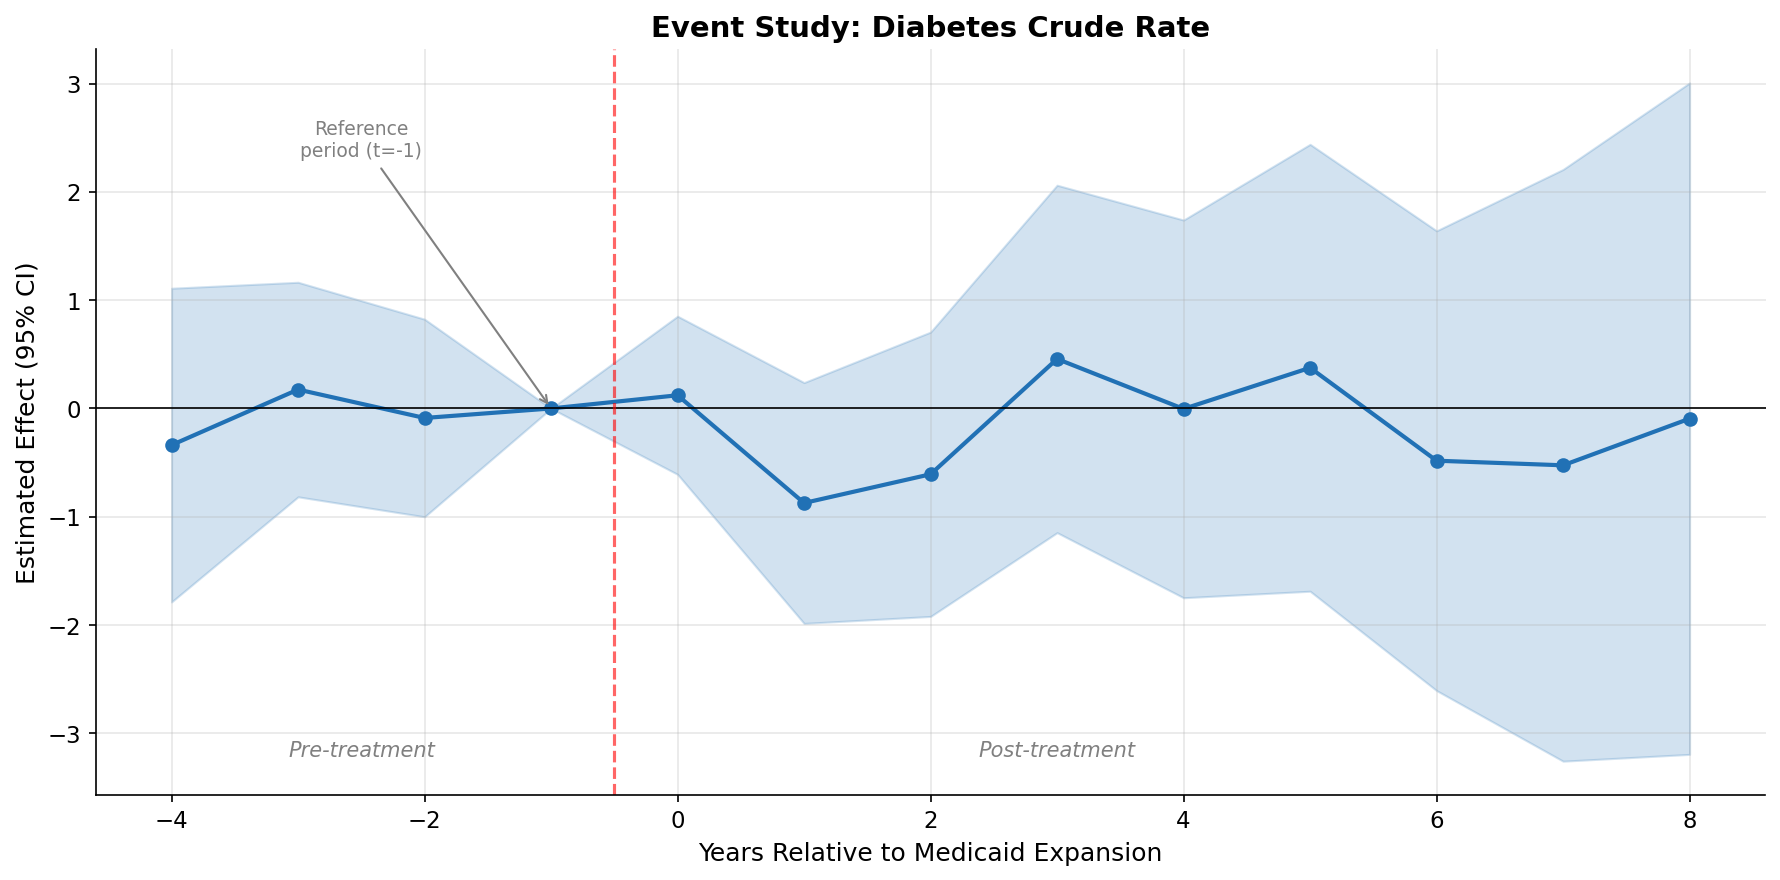

Saved: figures/event_study_diabetes_crude_rate.png

Event Study: diabetes_prevalence
 event_time      coef       se  ci_lower  ci_upper   pvalue
       -4.0  0.110412 0.219656 -0.321091  0.541916 0.615411
       -3.0 -0.114118 0.163657 -0.435614  0.207379 0.485923
       -2.0  0.108528 0.181385 -0.247794  0.464849 0.549877
       -1.0  0.000000 0.000000  0.000000  0.000000      NaN
        0.0  0.147600 0.139991 -0.127406  0.422606 0.292204
        1.0  0.064183 0.137347 -0.205628  0.333993 0.640474
        2.0  0.219279 0.189294 -0.152579  0.591137 0.247221
        3.0  0.038703 0.213886 -0.381465  0.458872 0.856473
        4.0  0.175246 0.246790 -0.309561  0.660054 0.477953
        5.0  0.225832 0.242036 -0.249635  0.701300 0.351217
        6.0  0.105606 0.266776 -0.418462  0.629674 0.692366
        7.0  0.104747 0.287521 -0.460073  0.669568 0.715770
        8.0  0.572518 0.359646 -0.133988  1.279024 0.112005


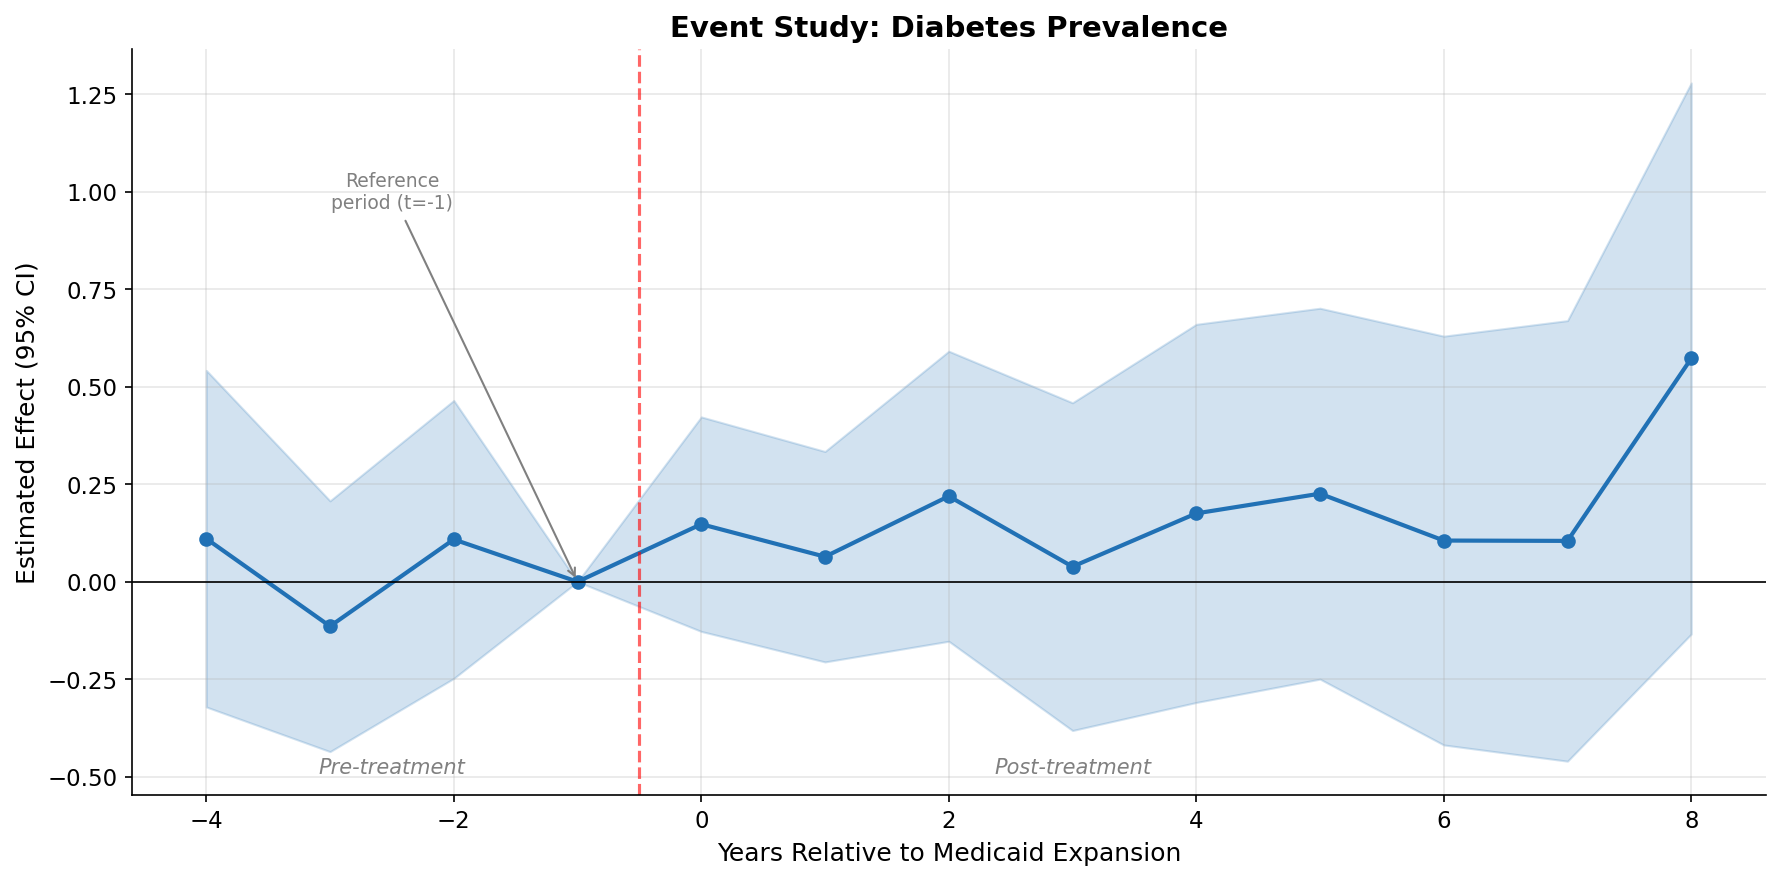

Saved: figures/event_study_diabetes_prevalence.png

Event Study: maternal_age_adj_rate
 event_time      coef       se  ci_lower  ci_upper   pvalue
       -4.0  0.013258 0.150629 -0.283517  0.310034 0.929936
       -3.0  0.144842 0.098906 -0.050026  0.339710 0.144427
       -2.0 -0.018470 0.108719 -0.232673  0.195733 0.865245
       -1.0  0.000000 0.000000  0.000000  0.000000      NaN
        0.0 -0.007810 0.100988 -0.206781  0.191162 0.938424
        1.0 -0.031690 0.100044 -0.228800  0.165420 0.751712
        2.0 -0.102265 0.145654 -0.389239  0.184708 0.483313
        3.0 -0.076817 0.163372 -0.398699  0.245065 0.638655
        4.0  0.098210 0.116420 -0.131165  0.327585 0.399771
        5.0 -0.046754 0.133209 -0.309209  0.215701 0.725922
        6.0 -0.169793 0.167715 -0.500232  0.160646 0.312406
        7.0 -0.330529 0.173629 -0.672619  0.011561 0.058193
        8.0 -0.092825 0.184130 -0.455605  0.269955 0.614649


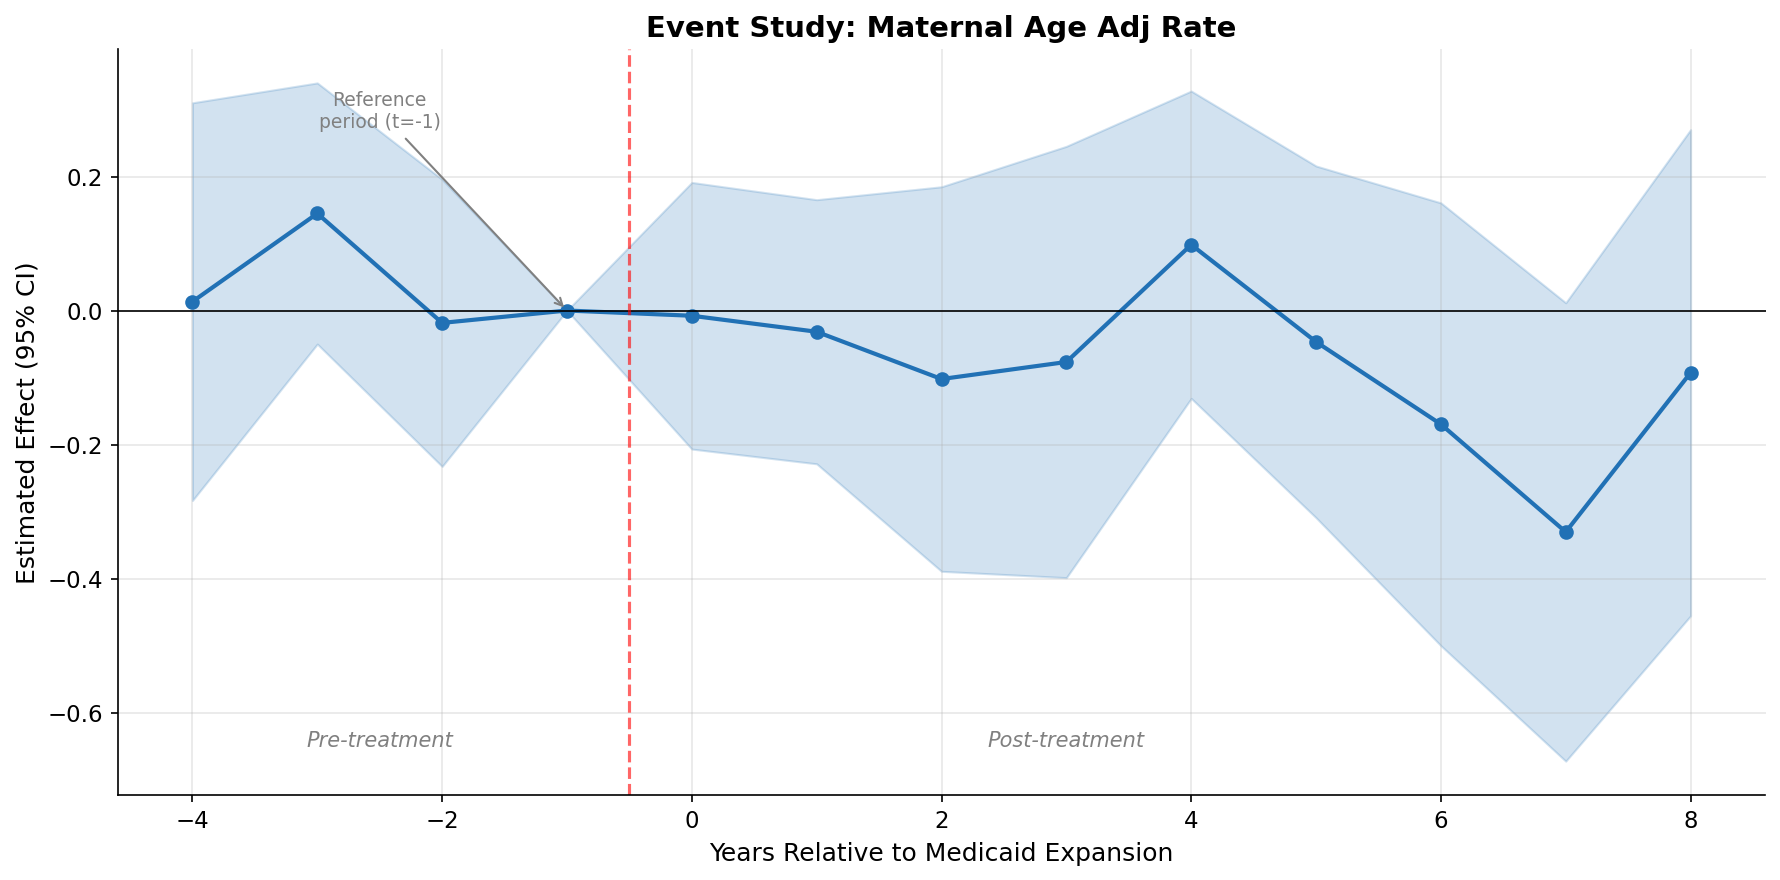

Saved: figures/event_study_maternal_age_adj_rate.png

Event Study: maternal_crude_rate
 event_time      coef       se  ci_lower  ci_upper   pvalue
       -4.0  0.026442 0.125454 -0.220733  0.273617 0.833253
       -3.0  0.160332 0.085396 -0.007919  0.328582 0.061703
       -2.0 -0.016755 0.091176 -0.196393  0.162883 0.854358
       -1.0  0.000000 0.000000  0.000000  0.000000      NaN
        0.0  0.021678 0.078183 -0.132361  0.175716 0.781821
        1.0 -0.025689 0.082360 -0.187958  0.136580 0.755390
        2.0 -0.064831 0.126998 -0.315048  0.185387 0.610198
        3.0 -0.024672 0.138044 -0.296651  0.247307 0.858310
        4.0  0.148480 0.097834 -0.044277  0.341237 0.130460
        5.0  0.004194 0.112356 -0.217174  0.225563 0.970252
        6.0 -0.107987 0.140462 -0.384731  0.168756 0.442793
        7.0 -0.243136 0.147797 -0.534331  0.048060 0.101310
        8.0 -0.025906 0.161922 -0.344930  0.293119 0.873030


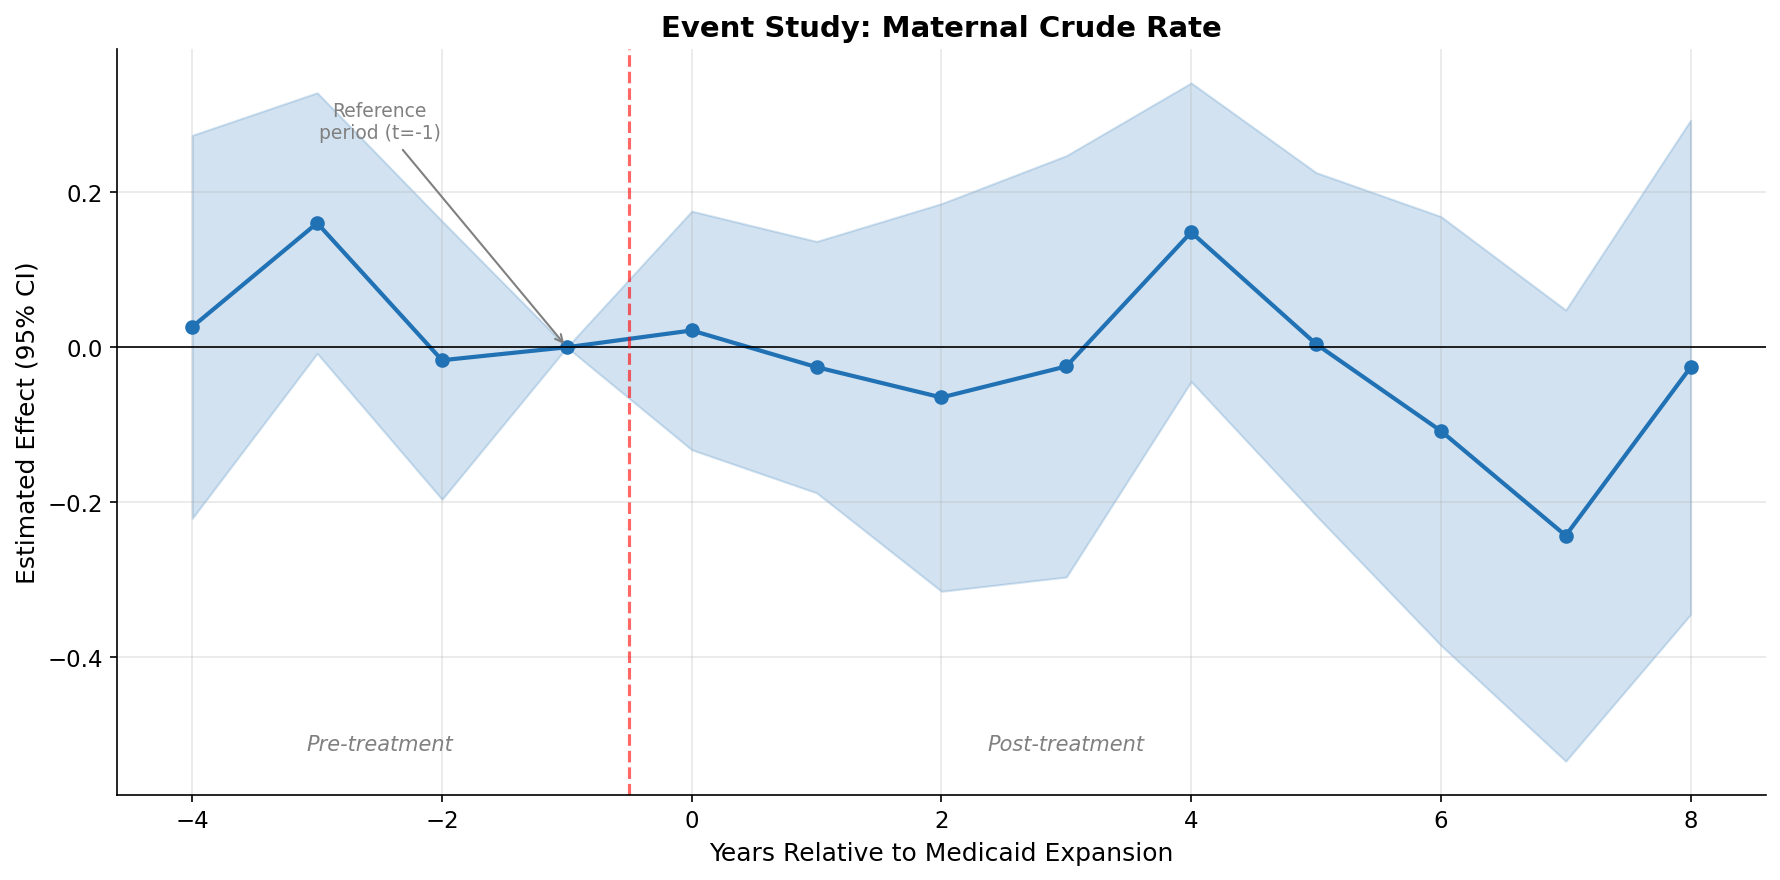

Saved: figures/event_study_maternal_crude_rate.png


In [9]:
# Run event studies for all available outcomes
event_study_results = {}

for outcome in outcome_vars:
    try:
        model, es_df = run_event_study(panel, outcome, controls=control_vars)
        event_study_results[outcome] = (model, es_df)
        
        # Print results
        print(f"\n{'='*60}")
        print(f"Event Study: {outcome}")
        print(f"{'='*60}")
        print(es_df[['event_time', 'coef', 'se', 'ci_lower', 'ci_upper', 'pvalue']].to_string(index=False))
        
        # Plot
        fig = plot_event_study(es_df, outcome)
        fig.savefig(f'../figures/event_study_{outcome}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: figures/event_study_{outcome}.png")
        
    except Exception as e:
        print(f"\n⚠️  Error with {outcome}: {e}")

---
## 4. Results Summary Table

In [10]:
# Compile results into a summary table
results_rows = []

for outcome in outcome_vars:
    row = {'outcome': outcome}
    
    # Simple DiD
    if outcome in simple_did_results:
        m = simple_did_results[outcome]
        row['simple_did_coef'] = m.params.get('treat_x_post', np.nan)
        row['simple_did_se'] = m.bse.get('treat_x_post', np.nan)
        row['simple_did_pval'] = m.pvalues.get('treat_x_post', np.nan)
    
    # TWFE
    if outcome in twfe_results:
        m = twfe_results[outcome]
        row['twfe_coef'] = m.params.get('post_expansion', np.nan)
        row['twfe_se'] = m.std_errors.get('post_expansion', np.nan)
        row['twfe_pval'] = m.pvalues.get('post_expansion', np.nan)
    
    results_rows.append(row)

results_df = pd.DataFrame(results_rows)

if len(results_df) > 0:
    print("\nResults Summary")
    print("=" * 80)
    display(results_df.round(4))
    
    # Save
    results_df.to_csv('../tables/main_results.csv', index=False)
    print("\nSaved: tables/main_results.csv")


Results Summary


,outcome,simple_did_coef,simple_did_se,simple_did_pval,twfe_coef,twfe_se,twfe_pval
0,allcause_age_adj_rate,-31.4534,12.0833,0.0092,0.1494,4.4885,0.9734
1,allcause_crude_rate,-47.8665,17.4568,0.0061,-1.3602,5.3637,0.7999
2,diabetes_age_adj_rate,-1.4980,0.7502,0.0458,-0.1568,0.3990,0.6944
3,diabetes_crude_rate,-2.0807,0.9857,0.0348,-0.1607,0.4690,0.7319
4,diabetes_prevalence,-0.3142,0.3322,0.3443,0.0991,0.1296,0.4448
5,maternal_age_adj_rate,-0.1343,0.1062,0.2061,-0.0213,0.0895,0.8119
6,maternal_crude_rate,-0.1115,0.0923,0.2269,-0.0021,0.0752,0.9776



Saved: tables/main_results.csv


---
## 5. TWFE Bias Discussion

### Why TWFE can be biased with staggered treatment

Recent econometrics literature (Goodman-Bacon 2021, de Chaisemartin & D'Haultfœuille 2020) shows that the standard TWFE estimator with staggered adoption can produce **biased estimates** because it implicitly uses already-treated units as controls ("bad comparisons").

The bias arises when:
1. Treatment effects are **heterogeneous** across cohorts or over time
2. Treatment timing is **staggered** (which it is in our setting)

### Solutions implemented in R scripts:

1. **Callaway & Sant'Anna (2021)** — `R/01_did_callaway_santanna.R`
   - Estimates group-time ATTs avoiding bad comparisons
   - Uses `did` package

2. **Sun & Abraham (2021)** — `R/03_sun_abraham.R`
   - Interaction-weighted estimator
   - Uses `fixest` package

3. **Goodman-Bacon Decomposition** — `R/04_twfe_diagnostics.R`
   - Decomposes TWFE into sub-estimates to diagnose bias
   - Uses `bacondecomp` package

### Proceed to:
- **R scripts** in `R/` folder for modern DiD estimators
- **`05_event_study.ipynb`** (optional) for additional event study visualizations
- **`06_synthetic_control.ipynb`** for single-state deep dive
- **`07_robustness_checks.ipynb`** for sensitivity analyses